# 14 - transfer learning test evaluation

Evaluate the three phase 2 checkpoints from notebook 13 (ResNet50, EfficientNet-B0, DenseNet121) against the held-out test set.

## setup

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

from citrus_transfer import IMAGENET_MEAN, IMAGENET_STD, build_model, count_trainable_params
from citrus_common import get_transforms, CitrusLeafDataset


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

DATA_ROOT = Path("processed/224")
CHECKPOINT_DIR = Path("checkpoints")

class_to_idx = {"aphids": 0, "gummosis": 1, "healthy": 2, "leaf_minnor": 3}
class_names = sorted(class_to_idx, key=class_to_idx.get)
architectures = ["resnet50", "efficientnet_b0", "densenet121"]


cuda


## helpers

specificity isn't in sklearn.metrics, so it's derived from the confusion matrix directly.

In [3]:
def compute_specificity(cm):
    """Per-class specificity from a confusion matrix: TN / (TN + FP)."""
    total = cm.sum()
    specs = []
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = total - tp - fp - fn
        specs.append(tn / (tn + fp))
    return np.array(specs)


def measure_latency(model, dataset, device, n_runs=100, n_warmup=10):
    model.eval()
    sample = dataset[0][0].unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(sample)
        if device.type == "cuda":
            torch.cuda.synchronize()

        times = []
        for _ in range(n_runs):
            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(sample)
            if device.type == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)

    times = np.array(times)
    return times.mean(), times.std()


This is the first and only time the test set is used for these three models. Checkpoints are loaded as-is from notebook 13, phase 2 — no training happens here.

resnet50

test accuracy: 0.9958 (239/240)

              precision    recall  f1-score   support

      aphids     1.0000    1.0000    1.0000        60
    gummosis     1.0000    1.0000    1.0000        65
     healthy     0.9808    1.0000    0.9903        51
 leaf_minnor     1.0000    0.9844    0.9921        64

    accuracy                         0.9958       240
   macro avg     0.9952    0.9961    0.9956       240
weighted avg     0.9959    0.9958    0.9958       240

      class  precision  recall (sensitivity)  specificity       f1
     aphids   1.000000              1.000000     1.000000 1.000000
   gummosis   1.000000              1.000000     1.000000 1.000000
    healthy   0.980769              1.000000     0.994709 0.990291
leaf_minnor   1.000000              0.984375     1.000000 0.992126


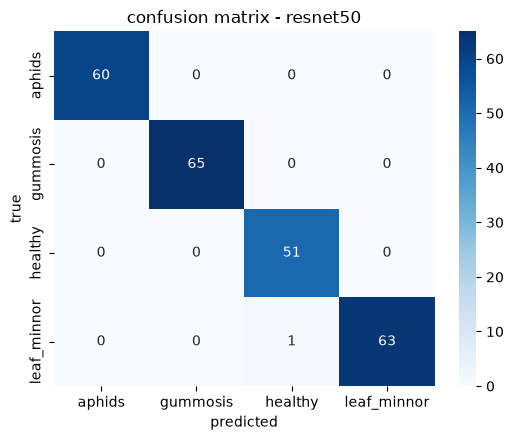

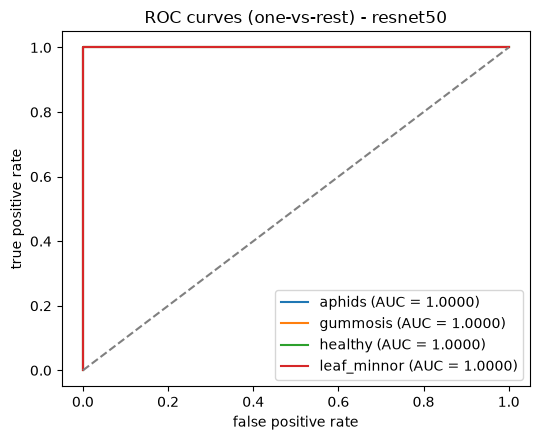


parameters: 23,770,820 (90.68 MB)
inference latency: 8.082 +/- 2.126 ms, throughput: 123.7 img/s

efficientnet_b0

test accuracy: 0.9292 (223/240)

              precision    recall  f1-score   support

      aphids     0.7895    1.0000    0.8824        60
    gummosis     0.9839    0.9385    0.9606        65
     healthy     1.0000    1.0000    1.0000        51
 leaf_minnor     1.0000    0.7969    0.8870        64

    accuracy                         0.9292       240
   macro avg     0.9433    0.9338    0.9325       240
weighted avg     0.9430    0.9292    0.9298       240

      class  precision  recall (sensitivity)  specificity       f1
     aphids   0.789474              1.000000     0.911111 0.882353
   gummosis   0.983871              0.938462     0.994286 0.960630
    healthy   1.000000              1.000000     1.000000 1.000000
leaf_minnor   1.000000              0.796875     1.000000 0.886957


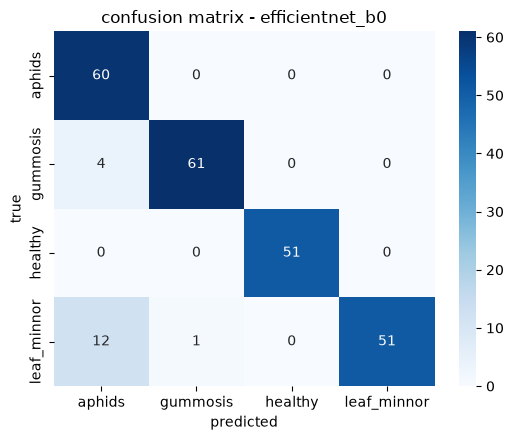

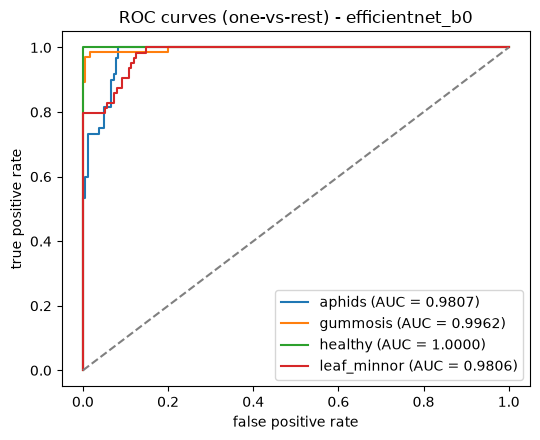


parameters: 4,172,032 (15.92 MB)
inference latency: 18.069 +/- 8.142 ms, throughput: 55.3 img/s

densenet121

test accuracy: 0.9875 (237/240)

              precision    recall  f1-score   support

      aphids     1.0000    1.0000    1.0000        60
    gummosis     0.9844    0.9692    0.9767        65
     healthy     1.0000    1.0000    1.0000        51
 leaf_minnor     0.9692    0.9844    0.9767        64

    accuracy                         0.9875       240
   macro avg     0.9884    0.9884    0.9884       240
weighted avg     0.9876    0.9875    0.9875       240

      class  precision  recall (sensitivity)  specificity       f1
     aphids   1.000000              1.000000     1.000000 1.000000
   gummosis   0.984375              0.969231     0.994286 0.976744
    healthy   1.000000              1.000000     1.000000 1.000000
leaf_minnor   0.969231              0.984375     0.988636 0.976744


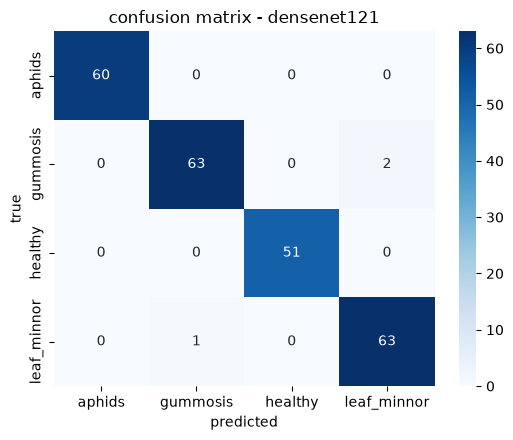

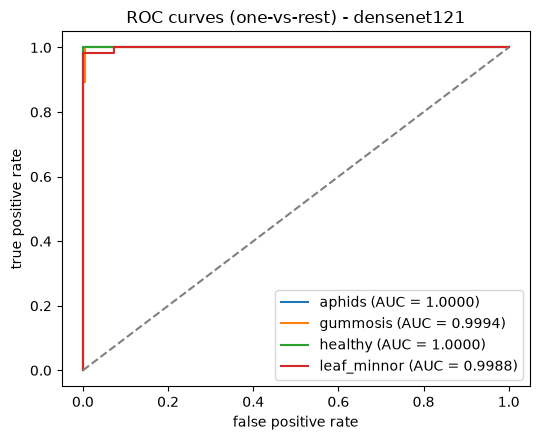


parameters: 7,085,572 (27.03 MB)
inference latency: 21.274 +/- 3.034 ms, throughput: 47.0 img/s



In [4]:
all_results = {}

for arch in architectures:
    print("=" * 70)
    print(arch)
    print("=" * 70)

    model = build_model(arch, num_classes=4)
    state_dict = torch.load(CHECKPOINT_DIR / f"tl_{arch}_phase2_best.pt", map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    model.to(device)

    test_transform = get_transforms(augment=False, mean=IMAGENET_MEAN, std=IMAGENET_STD, size=224)
    test_dataset = CitrusLeafDataset(root_dir=DATA_ROOT, split="test", transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            probs = torch.softmax(model(images), dim=1)
            y_true.append(labels.numpy())
            y_pred.append(probs.argmax(dim=1).cpu().numpy())
            y_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_probs = np.concatenate(y_probs)

    test_acc = (y_true == y_pred).mean()
    print(f"\ntest accuracy: {test_acc:.4f} ({(y_true == y_pred).sum()}/{len(y_true)})\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=range(4))
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

    cm = confusion_matrix(y_true, y_pred, labels=range(4))
    specificity = compute_specificity(cm)

    metrics_table = pd.DataFrame({
        "class": class_names,
        "precision": precision,
        "recall (sensitivity)": recall,
        "specificity": specificity,
        "f1": f1,
    })
    print(metrics_table.to_string(index=False))

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.title(f"confusion matrix - {arch}")
    plt.tight_layout()
    plt.show()

    y_true_bin = label_binarize(y_true, classes=range(4))
    per_class_auc = []
    plt.figure(figsize=(5.5, 4.5))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        auc = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
        per_class_auc.append(auc)
        plt.plot(fpr, tpr, label=f"{cname} (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("false positive rate")
    plt.ylabel("true positive rate")
    plt.title(f"ROC curves (one-vs-rest) - {arch}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    _, param_count = count_trainable_params(model)
    model_size_mb = param_count * 4 / 1024**2
    mean_lat, std_lat = measure_latency(model, test_dataset, device)
    throughput = 1000.0 / mean_lat

    print(f"\nparameters: {param_count:,} ({model_size_mb:.2f} MB)")
    print(f"inference latency: {mean_lat:.3f} +/- {std_lat:.3f} ms, throughput: {throughput:.1f} img/s\n")

    per_class = {
        cname: {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "sensitivity": float(recall[i]),
            "specificity": float(specificity[i]),
            "f1": float(f1[i]),
            "roc_auc": float(per_class_auc[i]),
        }
        for i, cname in enumerate(class_names)
    }

    results = {
        "architecture": arch,
        "test_accuracy": float(test_acc),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
        "per_class": per_class,
        "mean_roc_auc": float(np.mean(per_class_auc)),
        "param_count": int(param_count),
        "model_size_mb": float(model_size_mb),
        "mean_inference_latency_ms": float(mean_lat),
        "std_inference_latency_ms": float(std_lat),
        "throughput_images_per_sec": float(throughput),
    }

    with open(f"final_test_results_{arch}.json", "w") as f:
        json.dump(results, f, indent=2)

    all_results[arch] = results


## comparison across models

In [5]:
summary_df = pd.DataFrame([
    {
        "architecture": arch,
        "test_accuracy": res["test_accuracy"],
        "macro_precision": res["macro_precision"],
        "macro_recall": res["macro_recall"],
        "macro_f1": res["macro_f1"],
        "mean_roc_auc": res["mean_roc_auc"],
        "param_count": res["param_count"],
        "model_size_mb": res["model_size_mb"],
        "mean_inference_latency_ms": res["mean_inference_latency_ms"],
        "throughput_images_per_sec": res["throughput_images_per_sec"],
    }
    for arch, res in all_results.items()
]).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

summary_df


,architecture,test_accuracy,macro_precision,macro_recall,macro_f1,mean_roc_auc,param_count,model_size_mb,mean_inference_latency_ms,throughput_images_per_sec
0,resnet50,0.995833,0.995192,0.996094,0.995604,1.000000,23770820,90.678482,8.082305,123.727080
1,densenet121,0.987500,0.988401,0.988401,0.988372,0.999558,7085572,27.029312,21.273749,47.006289
2,efficientnet_b0,0.929167,0.943336,0.933834,0.932485,0.989402,4172032,15.915039,18.068612,55.344594


In [6]:
best_arch = summary_df.iloc[0]["architecture"]
best_acc = summary_df.iloc[0]["test_accuracy"]
fastest_row = summary_df.loc[summary_df["mean_inference_latency_ms"].idxmin()]

print(f"highest test accuracy: {best_arch} ({best_acc:.4f})")
print(f"lowest mean inference latency: {fastest_row['architecture']} ({fastest_row['mean_inference_latency_ms']:.3f} ms)")

eff_acc = summary_df.loc[summary_df["architecture"] == "efficientnet_b0", "test_accuracy"].iloc[0]
if eff_acc == summary_df["test_accuracy"].min():
    print("EfficientNet-B0 also scored the lowest test accuracy, matching the training instability seen in notebook 13.")
else:
    print("EfficientNet-B0 was not the weakest on test accuracy, despite the training instability seen in notebook 13.")


highest test accuracy: resnet50 (0.9958)
lowest mean inference latency: resnet50 (8.082 ms)
EfficientNet-B0 also scored the lowest test accuracy, matching the training instability seen in notebook 13.
